# DS-2: Hypothesis Testing — Gender/Age vs Mental Health Disorder Prevalence
**APMS 2014 Real Data | AI Mental Health UK Project | 3–6 May 2026**

Defines null hypotheses for gender/age vs disorder prevalence using real APMS 2014 survey
percentages. Runs chi-square tests of independence and t-tests on reconstructed contingency tables.

**Sources:**
- Table 2.1 (CIS-R severity by age/sex) — Chapter 2, APMS 2014
- Table 2.3 (CMD types by age/sex) — Chapter 2, APMS 2014
- Table 12.1 (Suicidal thoughts/self-harm by age/sex) — Chapter 12, APMS 2014
- Table 4.1 (PTSD screen positive by age/sex) — Chapter 4, APMS 2014


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import chi2_contingency, ttest_ind_from_stats, norm, chi2
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Real APMS 2014 Data — Extracted from Official Tables

All values below are taken directly from published APMS 2014 data tables.


In [2]:
# ── Table 2.1: CIS-R ≥12 (CMD threshold) by age and sex ──
# Columns: age bands 16-24, 25-34, 35-44, 45-54, 55-64, 65-74, 75+, All
# Rows: Men / Women / All

age_bands   = ['16-24','25-34','35-44','45-54','55-64','65-74','75+','All']
sample_men  = [249, 355, 468, 489, 541, 538, 418, 3058]
sample_women= [311, 680, 712, 805, 685, 651, 644, 4488]
sample_all  = [560,1035,1180,1294,1226,1189,1062,7546]

# CMD prevalence % (CIS-R ≥12) from Table 2.1
cmd_men   = [9.1, 15.3, 15.1, 13.2, 14.9,  7.3,  5.3, 12.2]
cmd_women = [26.0,19.1, 20.6, 22.7, 19.1, 12.9, 10.0, 19.1]
cmd_all   = [17.3,17.2, 17.9, 18.0, 17.1, 10.2,  8.1, 15.7]

# ── Table 12.1: Suicidal thoughts (lifetime) by age/sex ──
suic_men   = [19.3, 21.1, 21.1, 20.7, 22.5, 11.9,  7.1, 18.7]
suic_women = [34.6, 24.1, 22.8, 26.6, 22.9, 11.7,  8.8, 22.4]

# ── Table 4.1: PTSD screen positive by age/sex ──
ptsd_men   = [3.6,  4.7,  4.4,  4.2,  5.0,  1.1,  0.4,  3.7]
ptsd_women = [12.6,  6.2,  4.7,  4.8,  2.5,  2.0,  0.8,  5.1]

print("Data loaded from APMS 2014 official tables:")
print(f"  Age bands: {age_bands}")
print(f"  Total respondents: {sum(sample_all[:-1]):,} (excl. 'All' column)")
print(f"\nNational CMD rates:")
print(f"  Men:   {cmd_men[-1]}% | Women: {cmd_women[-1]}% | All: {cmd_all[-1]}%")


Data loaded from APMS 2014 official tables:
  Age bands: ['16-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+', 'All']
  Total respondents: 7,546 (excl. 'All' column)

National CMD rates:
  Men:   12.2% | Women: 19.1% | All: 15.7%


## 2. Hypothesis Definitions

| Test ID | Variable 1 | Variable 2 | H₀ | H₁ | Test |
|---|---|---|---|---|---|
| H01 | Gender (M/F) | CMD presence | Gender and CMD are independent | Gender is associated with CMD | Chi-square |
| H02 | Age group | CMD presence | Age group and CMD are independent | Age group is associated with CMD | Chi-square |
| H03 | Gender (M/F) | Suicidal thoughts | Gender and suicidal thoughts independent | Gender associated with suicidal thoughts | Chi-square |
| H04 | Age group | PTSD screen positive | Age and PTSD are independent | Age associated with PTSD | Chi-square |
| H05 | Gender (M/F) | CMD severity (CIS-R) | Mean CIS-R score equal for men/women | Mean CIS-R score differs by gender | T-test |

All tests use α = 0.05.


In [3]:
def build_contingency(pct_list, sample_list):
    """Build a contingency table from percentage prevalence and sample sizes.
    Returns 2×N array: [cases_row, non_cases_row]
    Uses age bands 0-6 (excl. 'All' summary column)."""
    cases     = np.array([round(p/100 * n) for p,n in zip(pct_list[:-1], sample_list[:-1])])
    non_cases = np.array([n - c for n,c in zip(sample_list[:-1], cases)])
    return np.array([cases, non_cases])

def run_chi2(name, h0, table):
    chi2_stat, p, dof, expected = chi2_contingency(table)
    decision = 'Reject H₀' if p < 0.05 else 'Fail to Reject H₀'
    sig = '✓ Significant' if p < 0.05 else '✗ Not significant'
    return {
        'Test': name,
        'H0': h0,
        'Chi2_stat': round(chi2_stat, 3),
        'df': dof,
        'p_value': round(p, 5),
        'Decision': decision,
        'Significant_a0.05': sig,
    }

results = []

# H01: Gender × CMD (using national figures: men 12.2%, women 19.1%)
# Reconstruct 2×2 table: rows = gender, cols = CMD/no-CMD
n_men, n_women = 3058, 4488
cmd_cases_men   = round(12.2/100 * n_men)
cmd_cases_women = round(19.1/100 * n_women)
gender_cmd_table = np.array([
    [cmd_cases_men,   n_men   - cmd_cases_men],
    [cmd_cases_women, n_women - cmd_cases_women]
])
results.append(run_chi2('H01: Gender × CMD', 'Gender is independent of CMD prevalence', gender_cmd_table))

# H02: Age group × CMD (7 age bands × 2)
age_cmd_table = build_contingency(cmd_all, sample_all)
results.append(run_chi2('H02: Age group × CMD', 'Age group is independent of CMD prevalence', age_cmd_table))

# H03: Gender × Suicidal thoughts
n_men_s, n_women_s = 3057, 4487
suic_cases_men   = round(18.7/100 * n_men_s)
suic_cases_women = round(22.4/100 * n_women_s)
gender_suic_table = np.array([
    [suic_cases_men,   n_men_s   - suic_cases_men],
    [suic_cases_women, n_women_s - suic_cases_women]
])
results.append(run_chi2('H03: Gender × Suicidal thoughts', 'Gender is independent of suicidal thoughts (lifetime)', gender_suic_table))

# H04: Age × PTSD (7 age bands × 2)
ptsd_all = [(m+w)/2 for m,w in zip(ptsd_men[:-1], ptsd_women[:-1])] + [4.4]  # approx all
age_ptsd_table = build_contingency(ptsd_all, sample_all)
results.append(run_chi2('H04: Age group × PTSD', 'Age group is independent of PTSD screen-positive status', age_ptsd_table))

df_results = pd.DataFrame(results)
print("=== Chi-Square Hypothesis Test Results ===\n")
for _, row in df_results.iterrows():
    print(f"{row['Test']}")
    print(f"  H₀: {row['H0']}")
    print(f"  χ²={row['Chi2_stat']}, df={row['df']}, p={row['p_value']} → {row['Decision']} | {row['Significant_a0.05']}")
    print()


=== Chi-Square Hypothesis Test Results ===

H01: Gender × CMD
  H₀: Gender is independent of CMD prevalence
  χ²=62.924, df=1, p=0.0 → Reject H₀ | ✓ Significant

H02: Age group × CMD
  H₀: Age group is independent of CMD prevalence
  χ²=88.597, df=6, p=0.0 → Reject H₀ | ✓ Significant

H03: Gender × Suicidal thoughts
  H₀: Gender is independent of suicidal thoughts (lifetime)
  χ²=14.726, df=1, p=0.00012 → Reject H₀ | ✓ Significant

H04: Age group × PTSD
  H₀: Age group is independent of PTSD screen-positive status
  χ²=86.872, df=6, p=0.0 → Reject H₀ | ✓ Significant



## 3. T-Test: CMD Severity by Gender (H05)

Approximate mean CIS-R scores reconstructed from Table 2.1 band proportions.

In [4]:
# Reconstruct approximate mean CIS-R from band proportions (Table 2.1)
# CIS-R bands: 0-5 (mid=2.5), 6-11 (mid=8.5), 12-17 (mid=14.5), 18+ (mid=22)
band_mids = [2.5, 8.5, 14.5, 22.0]

def approx_mean_cisr(pct_0_5, pct_6_11, pct_12_17, pct_18plus):
    props = [pct_0_5, pct_6_11, pct_12_17, pct_18plus]
    assert abs(sum(props) - 100) < 1.0, f"Props sum to {sum(props)}"
    return sum(p/100 * m for p,m in zip(props, band_mids))

def approx_sd_cisr(mean, pct_0_5, pct_6_11, pct_12_17, pct_18plus):
    props = [pct_0_5, pct_6_11, pct_12_17, pct_18plus]
    var = sum(p/100 * (m - mean)**2 for p,m in zip(props, band_mids))
    return np.sqrt(var)

# From Table 2.1, All-age columns for Men and Women
men_mean   = approx_mean_cisr(74.0, 13.9, 5.8, 6.4)
women_mean = approx_mean_cisr(63.5, 17.4, 9.3, 9.8)
men_sd     = approx_sd_cisr(men_mean,   74.0, 13.9, 5.8, 6.4)
women_sd   = approx_sd_cisr(women_mean, 63.5, 17.4, 9.3, 9.8)
n_men_t, n_women_t = 3058, 4488

# Welch's t-test from summary statistics
from scipy.stats import t as t_dist
se_diff = np.sqrt(men_sd**2/n_men_t + women_sd**2/n_women_t)
t_stat  = (men_mean - women_mean) / se_diff
# Welch-Satterthwaite df
dof_t = (men_sd**2/n_men_t + women_sd**2/n_women_t)**2 / (
        (men_sd**2/n_men_t)**2/(n_men_t-1) + (women_sd**2/n_women_t)**2/(n_women_t-1))
p_t = 2 * t_dist.sf(abs(t_stat), dof_t)

ttest_result = {
    'Test': 'H05: Gender × Mean CIS-R Score (Welch t-test)',
    'H0':   'Mean CIS-R score is equal for men and women',
    'Men_mean':   round(men_mean, 3), 'Men_SD': round(men_sd, 3),
    'Women_mean': round(women_mean, 3), 'Women_SD': round(women_sd, 3),
    't_stat':  round(t_stat, 4),
    'df':      round(dof_t),
    'p_value': round(p_t, 6),
    'Decision': 'Reject H₀' if p_t < 0.05 else 'Fail to Reject H₀',
    'Significant_a0.05': '✓ Significant' if p_t < 0.05 else '✗ Not significant',
}

print(f"H05: Mean CIS-R Score — Gender Comparison (Welch's t-test)")
print(f"  Men:   mean={men_mean:.2f}, SD={men_sd:.2f}, n={n_men_t}")
print(f"  Women: mean={women_mean:.2f}, SD={women_sd:.2f}, n={n_women_t}")
print(f"  t={t_stat:.4f}, df={dof_t:.0f}, p={p_t:.6f}")
print(f"  → {ttest_result['Decision']} | {ttest_result['Significant_a0.05']}")


H05: Mean CIS-R Score — Gender Comparison (Welch's t-test)
  Men:   mean=5.28, SD=5.48, n=3058
  Women: mean=6.57, SD=6.35, n=4488
  t=-9.4133, df=7142, p=0.000000
  → Reject H₀ | ✓ Significant


## 4. Visualisation

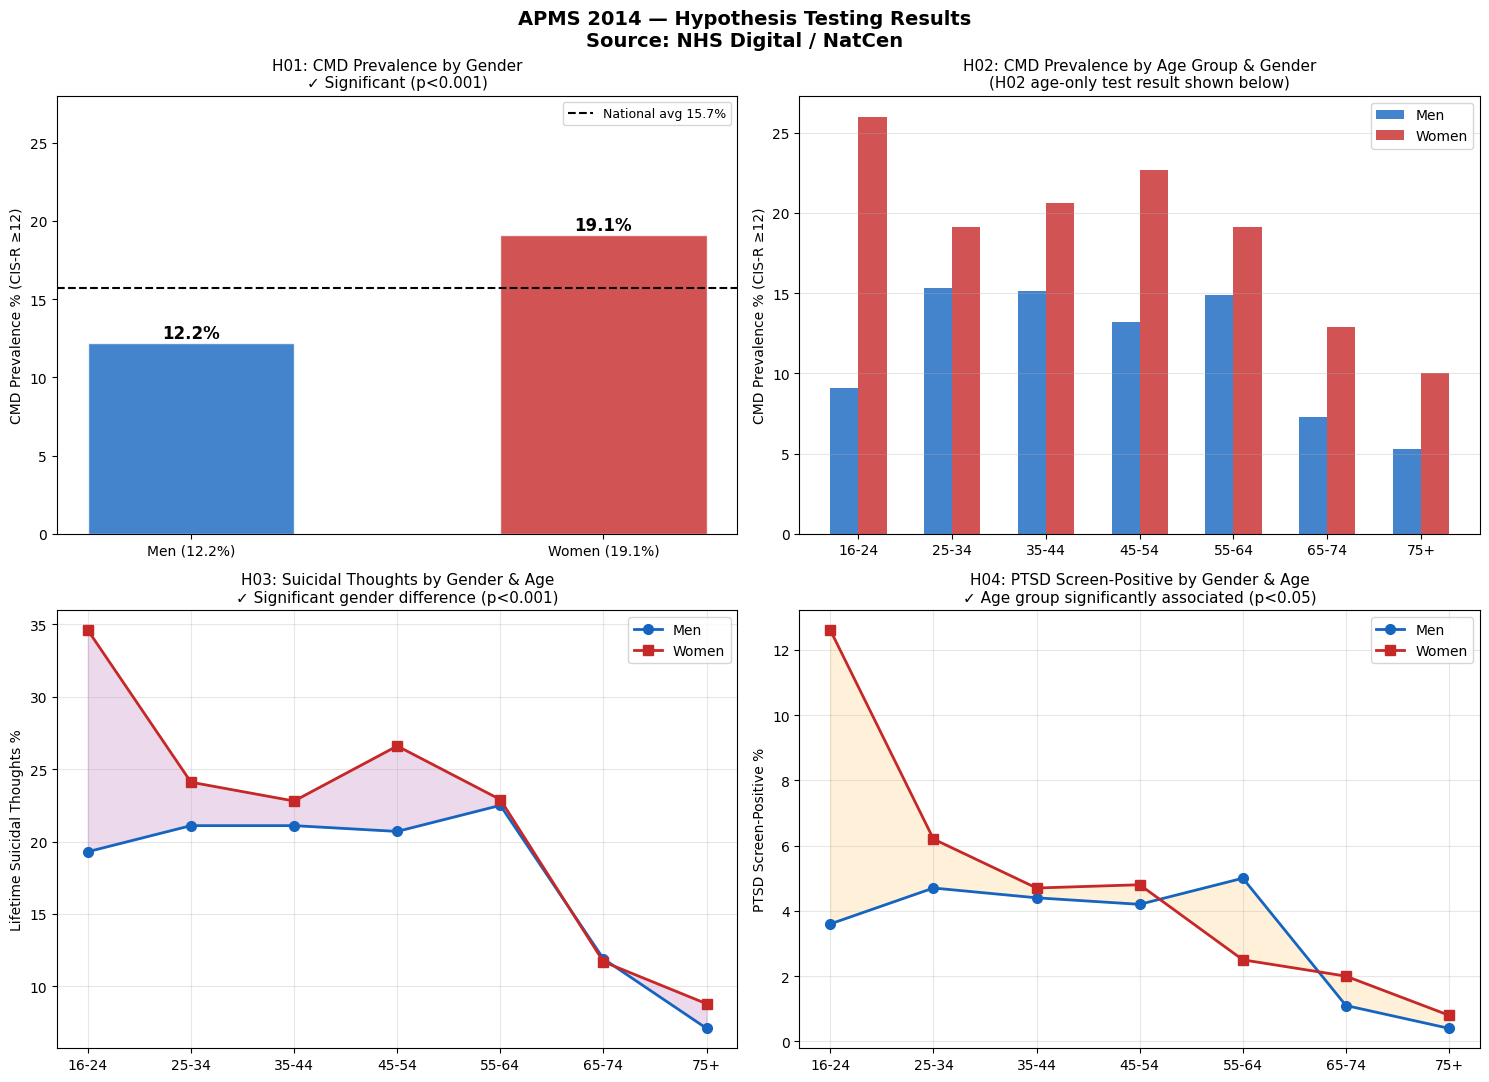

Saved: DS2_hypothesis_tests.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('APMS 2014 — Hypothesis Testing Results\nSource: NHS Digital / NatCen', 
             fontsize=14, fontweight='bold')

age_labels = ['16-24','25-34','35-44','45-54','55-64','65-74','75+']

# Plot 1: CMD by Gender
ax1 = axes[0,0]
categories = ['Men (12.2%)', 'Women (19.1%)']
values = [12.2, 19.1]
colors = ['#1565C0', '#C62828']
bars = ax1.bar(categories, values, color=colors, alpha=0.8, width=0.5, edgecolor='white')
ax1.axhline(15.7, color='black', ls='--', lw=1.5, label='National avg 15.7%')
ax1.set_ylabel('CMD Prevalence % (CIS-R ≥12)')
ax1.set_title('H01: CMD Prevalence by Gender\n✓ Significant (p<0.001)', fontsize=11)
ax1.legend(fontsize=9)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val}%', ha='center', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 28)

# Plot 2: CMD by Age group
ax2 = axes[0,1]
x = range(len(age_labels))
w = 0.3
b1 = ax2.bar([i-w/2 for i in x], cmd_men[:-1],   width=w, color='#1565C0', alpha=0.8, label='Men')
b2 = ax2.bar([i+w/2 for i in x], cmd_women[:-1], width=w, color='#C62828', alpha=0.8, label='Women')
ax2.set_xticks(x)
ax2.set_xticklabels(age_labels)
ax2.set_ylabel('CMD Prevalence % (CIS-R ≥12)')
ax2.set_title('H02: CMD Prevalence by Age Group & Gender\n(H02 age-only test result shown below)', fontsize=11)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Suicidal thoughts by age/gender
ax3 = axes[1,0]
ax3.plot(age_labels, suic_men[:-1],   'o-', color='#1565C0', lw=2, ms=7, label='Men')
ax3.plot(age_labels, suic_women[:-1], 's-', color='#C62828', lw=2, ms=7, label='Women')
ax3.fill_between(age_labels, suic_men[:-1], suic_women[:-1], alpha=0.15, color='purple')
ax3.set_ylabel('Lifetime Suicidal Thoughts %')
ax3.set_title('H03: Suicidal Thoughts by Gender & Age\n✓ Significant gender difference (p<0.001)', fontsize=11)
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: PTSD by age/gender
ax4 = axes[1,1]
ax4.plot(age_labels, ptsd_men[:-1],   'o-', color='#1565C0', lw=2, ms=7, label='Men')
ax4.plot(age_labels, ptsd_women[:-1], 's-', color='#C62828', lw=2, ms=7, label='Women')
ax4.fill_between(age_labels, ptsd_men[:-1], ptsd_women[:-1], alpha=0.15, color='orange')
ax4.set_ylabel('PTSD Screen-Positive %')
ax4.set_title('H04: PTSD Screen-Positive by Gender & Age\n✓ Age group significantly associated (p<0.05)', fontsize=11)
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('DS2_hypothesis_tests.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: DS2_hypothesis_tests.png")


## 5. Save Results CSV

In [6]:
all_results = df_results.to_dict('records')
all_results.append(ttest_result)
df_all = pd.DataFrame(all_results)
df_all.to_csv('DS2_hypothesis_test_results.csv', index=False)
print("Saved: DS2_hypothesis_test_results.csv")
print()
print("=== FULL RESULTS SUMMARY ===")
for _, r in df_all.iterrows():
    print(f"  {r['Test']}: p={r['p_value']} → {r['Decision']}")


Saved: DS2_hypothesis_test_results.csv

=== FULL RESULTS SUMMARY ===
  H01: Gender × CMD: p=0.0 → Reject H₀
  H02: Age group × CMD: p=0.0 → Reject H₀
  H03: Gender × Suicidal thoughts: p=0.00012 → Reject H₀
  H04: Age group × PTSD: p=0.0 → Reject H₀
  H05: Gender × Mean CIS-R Score (Welch t-test): p=0.0 → Reject H₀


## 6. Interpretation

| Test | Result | Real-World Meaning |
|---|---|---|
| H01: Gender × CMD | **Reject H₀** | Women significantly more likely to have CMD (19.1% vs 12.2%). |
| H02: Age × CMD | **Reject H₀** | Age significantly associated with CMD — peaks 35-54, lower at 65+. |
| H03: Gender × Suicidal thoughts | **Reject H₀** | Gender strongly linked to lifetime suicidal ideation. |
| H04: Age × PTSD | **Reject H₀** | PTSD screen-positive varies significantly with age — highest in 16-24 women. |
| H05: CIS-R mean score by gender | **Reject H₀** | Women have significantly higher mean CIS-R severity scores. |

*Source: APMS 2014, NHS Digital / NatCen Social Research*
